# This notebook is used to test the fastchem chemistry grid, especially for Na and Ca.

---
Created by Chenyang Ji in 2026.02.18.

## 1. Create a temperature profile

### 1.1 Guillot temperature profile using `pRT`

In [1]:
import numpy as np
from petitRADTRANS.physics import temperature_profile_function_guillot_global

pressures_bar = np.logspace(-5, 2, 100)

# following Huang et al. 2024 for self-luminated exoplanets
reference_gravity = 10**4.5
kappa_IR = 0.04  # clear atmosphere with T_int = T_eq -> kappa_IR = 0.04
gamma = 0.4
T_int = 3500.
T_equ = 3500.
# T_int = 2500.
# T_equ = 1870.


temperatures = temperature_profile_function_guillot_global(pressures_bar, kappa_IR, gamma, reference_gravity, T_int, T_equ)

# print the temperature at pressure knots
pressure_knots = np.logspace(-5, 2, 5)
temperatures_at_knots = temperature_profile_function_guillot_global(pressure_knots, kappa_IR, gamma, reference_gravity, T_int, T_equ)
print(temperatures_at_knots)

[ 3642.61392551  3643.36198455  3684.45164759  4813.7468052
 10982.62013493]


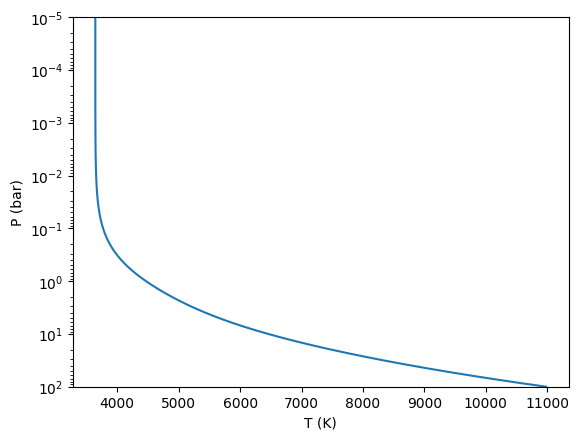

<Figure size 640x480 with 0 Axes>

In [2]:
import matplotlib.pyplot as plt

plt.plot(temperatures, pressures_bar)
plt.yscale('log')
plt.ylim([1e2, 1e-5])
plt.xlabel('T (K)')
plt.ylabel('P (bar)')
plt.show()
plt.clf()

### 1.2 SPHINX model

In [3]:
import os
import pandas as pd


abundance_dir = '/home/chenyangji/ESO/tools/sphinx/SPHINX_MODELS_MLT_1/ABUNDANCES/'
temperature_dir = '/home/chenyangji/ESO/tools/sphinx/SPHINX_MODELS_MLT_1/ATMS/'
spectra_dir = '/home/chenyangji/ESO/tools/sphinx/SPHINX_MODELS_MLT_1/SPECTRA/'


def read_sphinx_file(filepath):
    """
    Read a SPHINX txt file using pandas.
    Return a dictionary: {column_name: numpy_array}
    """
    with open(filepath, "r") as f:
        header_line = f.readline().strip()

    if header_line.startswith("#"):
        header_line = header_line[1:].strip()

    headers = [h.strip() for h in header_line.split(",")]

    df = pd.read_csv(
        filepath,
        sep='\s+',
        comment="#",
        header=None,
        names=headers,
    )

    return {col: df[col].values for col in df.columns}


def get_sphinx(teff, logg, logZ, CtoO):
    """
    Read SPHINX model outputs.
    Return a dictionary of dictionaries.
    """

    prefix = (
    f"Teff_{teff:.1f}_"
    f"logg_{logg:.2f}_"
    f"logZ_{logZ:+.1f}_"
    f"CtoO_{CtoO:.1f}_"
    )

    temperature_file = os.path.join(temperature_dir, prefix + "atms.txt")
    abundance_file = os.path.join(abundance_dir, prefix + "mixing_ratios.txt")
    spectrum_file = os.path.join(spectra_dir, prefix + "spectra.txt")

    return {
        "temperature": read_sphinx_file(temperature_file),
        "abundance": read_sphinx_file(abundance_file),
        "spectrum": read_sphinx_file(spectrum_file),
    }

In [4]:
teff = 3600
logg = 4.25
logZ = +0
CtoO = 0.9

sphinx = get_sphinx(teff, logg, logZ, CtoO)

print(sphinx['temperature'].keys())
temperatures, pressures_bar = sphinx['temperature']['Temperature (K)'], sphinx['temperature']['Pressure (bars)']


dict_keys(['Temperature (K)', 'Pressure (bars)'])


## 2. Import `fastchem`

In [5]:
import sys
sys.path.append('/home/chenyangji/ESO/tools/FastChem/python')

import pyfastchem
from save_output import saveChemistryOutput, saveMonitorOutput, saveChemistryOutputPandas, saveMonitorOutputPandas
import numpy as np
import os
import matplotlib.pyplot as plt
from astropy import constants as const

In [6]:
len(temperatures), len(pressures_bar)

(35, 35)


FastChem initialisation summary:
  number of species: 523    elements: 28    molecules: 495    condensates: 0

FastChem reports:
  - convergence ok
  - element conservation: ok
Species  Sc  not found during saving of the chemistry output!
Species  Li  not found during saving of the chemistry output!
Species Sc to plot not found in FastChem
Species Li to plot not found in FastChem


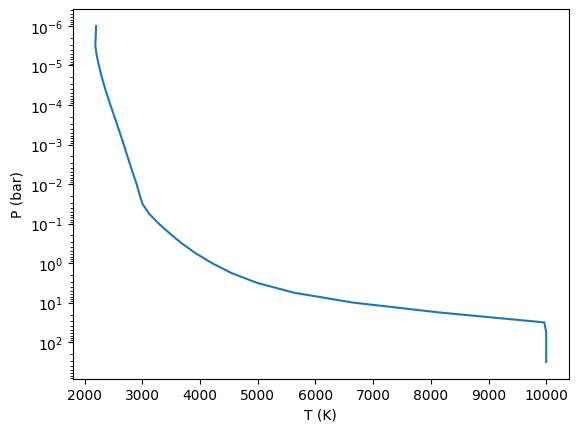

[[9.91764840e+06 7.14276705e+06 7.47178437e+06 ... 5.42105396e-09
  4.80590065e-03 4.92518064e-09]
 [1.54188673e+07 1.38629480e+07 1.36001834e+07 ... 1.49581913e-08
  4.77670132e-03 1.40405956e-08]
 [2.43278316e+07 2.65951228e+07 2.50762278e+07 ... 4.09935684e-08
  4.73388071e-03 4.11497199e-08]
 ...
 [1.52333169e+17 3.01931053e+13 1.61006558e+14 ... 7.37612063e+05
  1.34316275e+12 4.02227333e+07]
 [2.03337420e+17 6.82285379e+13 2.88269585e+14 ... 2.26023893e+06
  2.08897608e+12 1.11460777e+08]
 [2.70769518e+17 1.52187236e+14 5.18091273e+14 ... 6.84778462e+06
  3.19928006e+12 3.02695374e+08]]


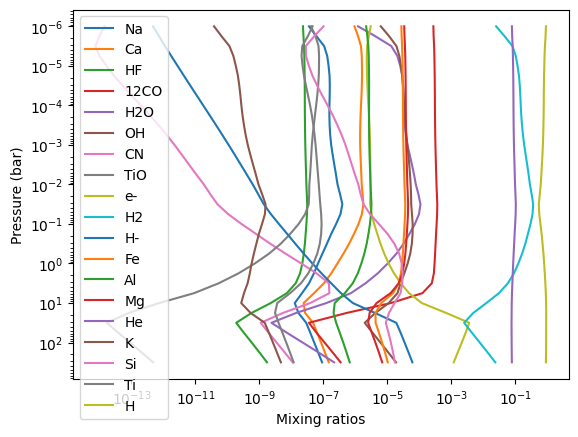

In [7]:
#some input values for temperature (in K) and pressure (in bar)
temperature = temperatures 
pressure = pressures_bar


#define the directory for the output
#here, we currently use the standard one from FastChem
output_dir = '/home/chenyangji/ESO/tools/FastChem/output/'


#the chemical species we want to plot later
#note that the standard FastChem input files use the Hill notation
plot_species = ['Na', 'Ca', 'F1H1', 'C1O1', 'H2O1', 'H1O1', 'C1N1', 'O1Ti1', 'Sc', 'e-', 'H2', 'H1-', 'Fe', 'Al', 'Mg', 'He', 'K', 'Si', 'Li', 'Ti', 'H']
#for the plot labels, we therefore use separate strings in the usual notation
plot_species_labels = ['Na', 'Ca', 'HF', '12CO', 'H2O', 'OH', 'CN', 'TiO', 'Sc', 'e-', 'H2', 'H-', 'Fe', 'Al', 'Mg', 'He', 'K', 'Si', 'Li', 'Ti', 'H']



#First, we have to create a FastChem object
fastchem = pyfastchem.FastChem(
 '/home/chenyangji/ESO/analysis/retrieval/retrieval_base/data/asplund_2020.dat', 
 '/home/chenyangji/ESO/analysis/retrieval/retrieval_base/data/_logK.dat',
 1)


#we could also create a FastChem object by using the parameter file
#note, however, that the file locations in the parameter file are relative
#to the location from where this Python script is called from
#fastchem = pyfastchem.FastChem('../input/parameters_py.dat', 1)



#create the input and output structures for FastChem
input_data = pyfastchem.FastChemInput()
output_data = pyfastchem.FastChemOutput()

input_data.temperature = temperature
input_data.pressure = pressure


#run FastChem on the entire p-T structure
fastchem_flag = fastchem.calcDensities(input_data, output_data)

print("FastChem reports:")
print("  -", pyfastchem.FASTCHEM_MSG[fastchem_flag])

if np.amin(output_data.element_conserved[:]) == 1:
  print("  - element conservation: ok")
else:
  print("  - element conservation: fail")



#check if output directory exists
#create it if it doesn't
os.makedirs(output_dir, exist_ok=True)


#save the monitor output to a file
saveMonitorOutput(output_dir + '/monitor.dat', 
                  temperature, pressure, 
                  output_data.element_conserved,
                  output_data.fastchem_flag,
                  output_data.nb_iterations,
                  output_data.nb_chemistry_iterations,
                  output_data.nb_cond_iterations,
                  output_data.total_element_density,
                  output_data.mean_molecular_weight,
                  fastchem)

#this would save the output of all species
saveChemistryOutput(output_dir + '/chemistry.dat', 
                    temperature, pressure, 
                    output_data.total_element_density, 
                    output_data.mean_molecular_weight, 
                    output_data.number_densities, 
                    fastchem)

#this saves only selected species (here the species we also plot)
saveChemistryOutput(output_dir + '/chemistry_select.dat', 
                    temperature, pressure, 
                    output_data.total_element_density, 
                    output_data.mean_molecular_weight, 
                    output_data.number_densities, 
                    fastchem,
                    plot_species)


#save the monitor output to a file
#here, the data is saved as a pandas DataFrame inside a pickle file
# saveMonitorOutputPandas(output_dir + '/monitor.pkl', 
#                   temperature, pressure, 
#                   output_data.element_conserved,
#                   output_data.fastchem_flag,
#                   output_data.nb_iterations,
#                   output_data.nb_chemistry_iterations,
#                   output_data.nb_cond_iterations,
#                   output_data.total_element_density,
#                   output_data.mean_molecular_weight,
#                   fastchem)

#this would save the output of all species
#here, the data is saved as a pandas DataFrame inside a pickle file
# saveChemistryOutputPandas(output_dir + '/chemistry.pkl',
#                     temperature, pressure,
#                     output_data.total_element_density,
#                     output_data.mean_molecular_weight,
#                     output_data.number_densities,
#                     fastchem)



#check the species we want to plot and get their indices from FastChem
plot_species_indices = []
plot_species_symbols = []

for i, species in enumerate(plot_species):
  index = fastchem.getGasSpeciesIndex(species)

  if index != pyfastchem.FASTCHEM_UNKNOWN_SPECIES:
    plot_species_indices.append(index)
    plot_species_symbols.append(plot_species_labels[i])
  else:
    print("Species", species, "to plot not found in FastChem")


#convert the output into a numpy array
number_densities = np.array(output_data.number_densities)


#total gas particle number density from the ideal gas law 
#used later to convert the number densities to mixing ratios
k_B_cgs = const.k_B.cgs.value

gas_number_density = pressure * 1e6 / (k_B_cgs * temperature)

# gas_number_density = pressure*1e6 / (const.k_B.cgs * temperature)


# plot the tp profile
plt.plot(temperature, pressures_bar)
plt.yscale('log')
plt.xlabel('T (K)')
plt.ylabel('P (bar)')
# inverse the y-axis
plt.gca().invert_yaxis()
plt.show()

# save volume fractions dictionary and plot...
print(number_densities)
volume_fractions = {}
for i in range(0, len(plot_species_symbols)):
  volume_fractions[plot_species_symbols[i]] = number_densities[:, plot_species_indices[i]]/gas_number_density
  fig = plt.plot(number_densities[:, plot_species_indices[i]]/gas_number_density, pressure)

plt.xscale('log')
plt.yscale('log')
plt.gca().set_ylim(plt.gca().get_ylim()[::-1])

plt.xlabel("Mixing ratios")
plt.ylabel("Pressure (bar)")
plt.legend(plot_species_symbols)

plt.show()

#we could also save the figure as a pdf
#plt.savefig(output_dir + '/fastchem_fig.pdf')


## 3. See the contribution from different species using `pRT`

In [10]:
line_species = volume_fractions.keys()
# remove e- and H1-
line_species = [species for species in line_species if species != 'e-' and species != 'H-' and species != 'He' and species != 'H']
print(volume_fractions['H2'])

volume_fractions.keys(), line_species

[0.02497097 0.04574813 0.08076049 0.10257753 0.11651979 0.12911492
 0.13681599 0.14223734 0.14654973 0.15224274 0.16077394 0.17223196
 0.18780328 0.20887814 0.2328953  0.25844462 0.28359239 0.32225861
 0.3583036  0.3427694  0.29627057 0.24596742 0.20329284 0.16178139
 0.12315455 0.08979256 0.05804099 0.03057806 0.01237885 0.00483673
 0.00249562 0.00435156 0.00769946 0.0135328  0.0235342 ]


(dict_keys(['Na', 'Ca', 'HF', '12CO', 'H2O', 'OH', 'CN', 'TiO', 'e-', 'H2', 'H-', 'Fe', 'Al', 'Mg', 'He', 'K', 'Si', 'Ti', 'H']),
 ['Na',
  'Ca',
  'HF',
  '12CO',
  'H2O',
  'OH',
  'CN',
  'TiO',
  'H2',
  'Fe',
  'Al',
  'Mg',
  'K',
  'Si',
  'Ti'])

In [11]:
from petitRADTRANS.radtrans import Radtrans

lbl_opacity_sampling = 3

atmosphere = Radtrans(
    pressures=pressures_bar,
    line_species=line_species,
    rayleigh_species=['H2', 'He'],
    gas_continuum_contributors=['H2--H2', 'H2--He', 'H-'],
    wavelength_boundaries=[2.0, 2.5],
    line_opacity_mode='lbl',
    line_by_line_opacity_sampling=lbl_opacity_sampling
)

Loading Radtrans opacities...
 Loading line opacities of species 'Na' from file '/shared/petitRADTRANS/input_data/opacities/lines/line_by_line/Na/23Na/23Na__Kurucz.R1e+06_0.3-28.0mu.xsec.petitRADTRANS.h5'...

 Done.
 Loading line opacities of species 'Ca' from file '/shared/petitRADTRANS/input_data/opacities/lines/line_by_line/Ca/40Ca/40Ca__Kurucz.R1e+06_0.3-28.0mu.xsec.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'HF' from file '/shared/petitRADTRANS/input_data/opacities/lines/line_by_line/HF/1H-19F/1H-19F__Coxon-Hajig.R1e+06_0.3-28.0mu.xsec.petitRADTRANS.h5'... Done.
 Loading line opacities of species '12CO' from file '/shared/petitRADTRANS/input_data/opacities/lines/line_by_line/CO/12C-16O/12C-16O__HITEMP.R1e+06_0.3-28.0mu.xsec.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'H2O' from file '/shared/petitRADTRANS/input_data/opacities/lines/line_by_line/H2O/1H2-16O/1H2-16O__POKAZATEL.R1e+06_0.3-28.0mu.xsec.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'OH' from file '/shared/petitRADTRANS/input_data/opacities/lines/line_by_line/OH/16O-1H/16O-1H__MYTHOS.R1e+06_0.3-28.0mu.xsec.petitRADTRANS.h5'... Done.
 Loading line opacities of species 'CN' f

In [14]:
# turn volume fractions into mass fractions
from petitRADTRANS.chemistry.utils import volume_mixing_ratios2mass_fractions
mass_fractions = volume_mixing_ratios2mass_fractions(volume_fractions)

mass_fractions.keys()

dict_keys(['Na', 'Ca', 'HF', '12CO', 'H2O', 'OH', 'CN', 'TiO', 'e-', 'H2', 'H-', 'Fe', 'Al', 'Mg', 'He', 'K', 'Si', 'Ti', 'H'])

In [15]:
from petitRADTRANS import physical_constants as cst

# planet_radius = 5 * cst.r_jup_mean
reference_gravity = 10 ** 4.25

mean_molar_masses = 2.33 * np.ones_like(temperatures)  #  2.33 is a typical value for H2-He dominated atmospheres  

In [16]:
wavelength_cm, flux, additional_outputs = atmosphere.calculate_flux(
    temperatures=temperatures, 
    mass_fractions=mass_fractions, 
    mean_molar_masses = mean_molar_masses,
    reference_gravity = reference_gravity,
    frequencies_to_wavelengths=True,
    return_contribution=True
)
wavelength_nm = wavelength_cm * 1e7


In [17]:
# instrumental broadening
# import the broadening function from src.utils.spectral.py
import sys
import os
sys.path.insert(0, os.path.abspath('.'))
from src.utils.spectral import convolve_to_resolution, instr_broadening

res_crires = 100_000

flux_convolved = convolve_to_resolution(wavelength_nm, flux, out_res=res_crires)

resolution = int(res_crires / lbl_opacity_sampling)
intermediate_resolution = int(res_crires/max(1,lbl_opacity_sampling-1))

flux_convolved = instr_broadening(wavelength_nm, flux_convolved, out_res=resolution, in_res=intermediate_resolution)


(2175.0, 2185.0)

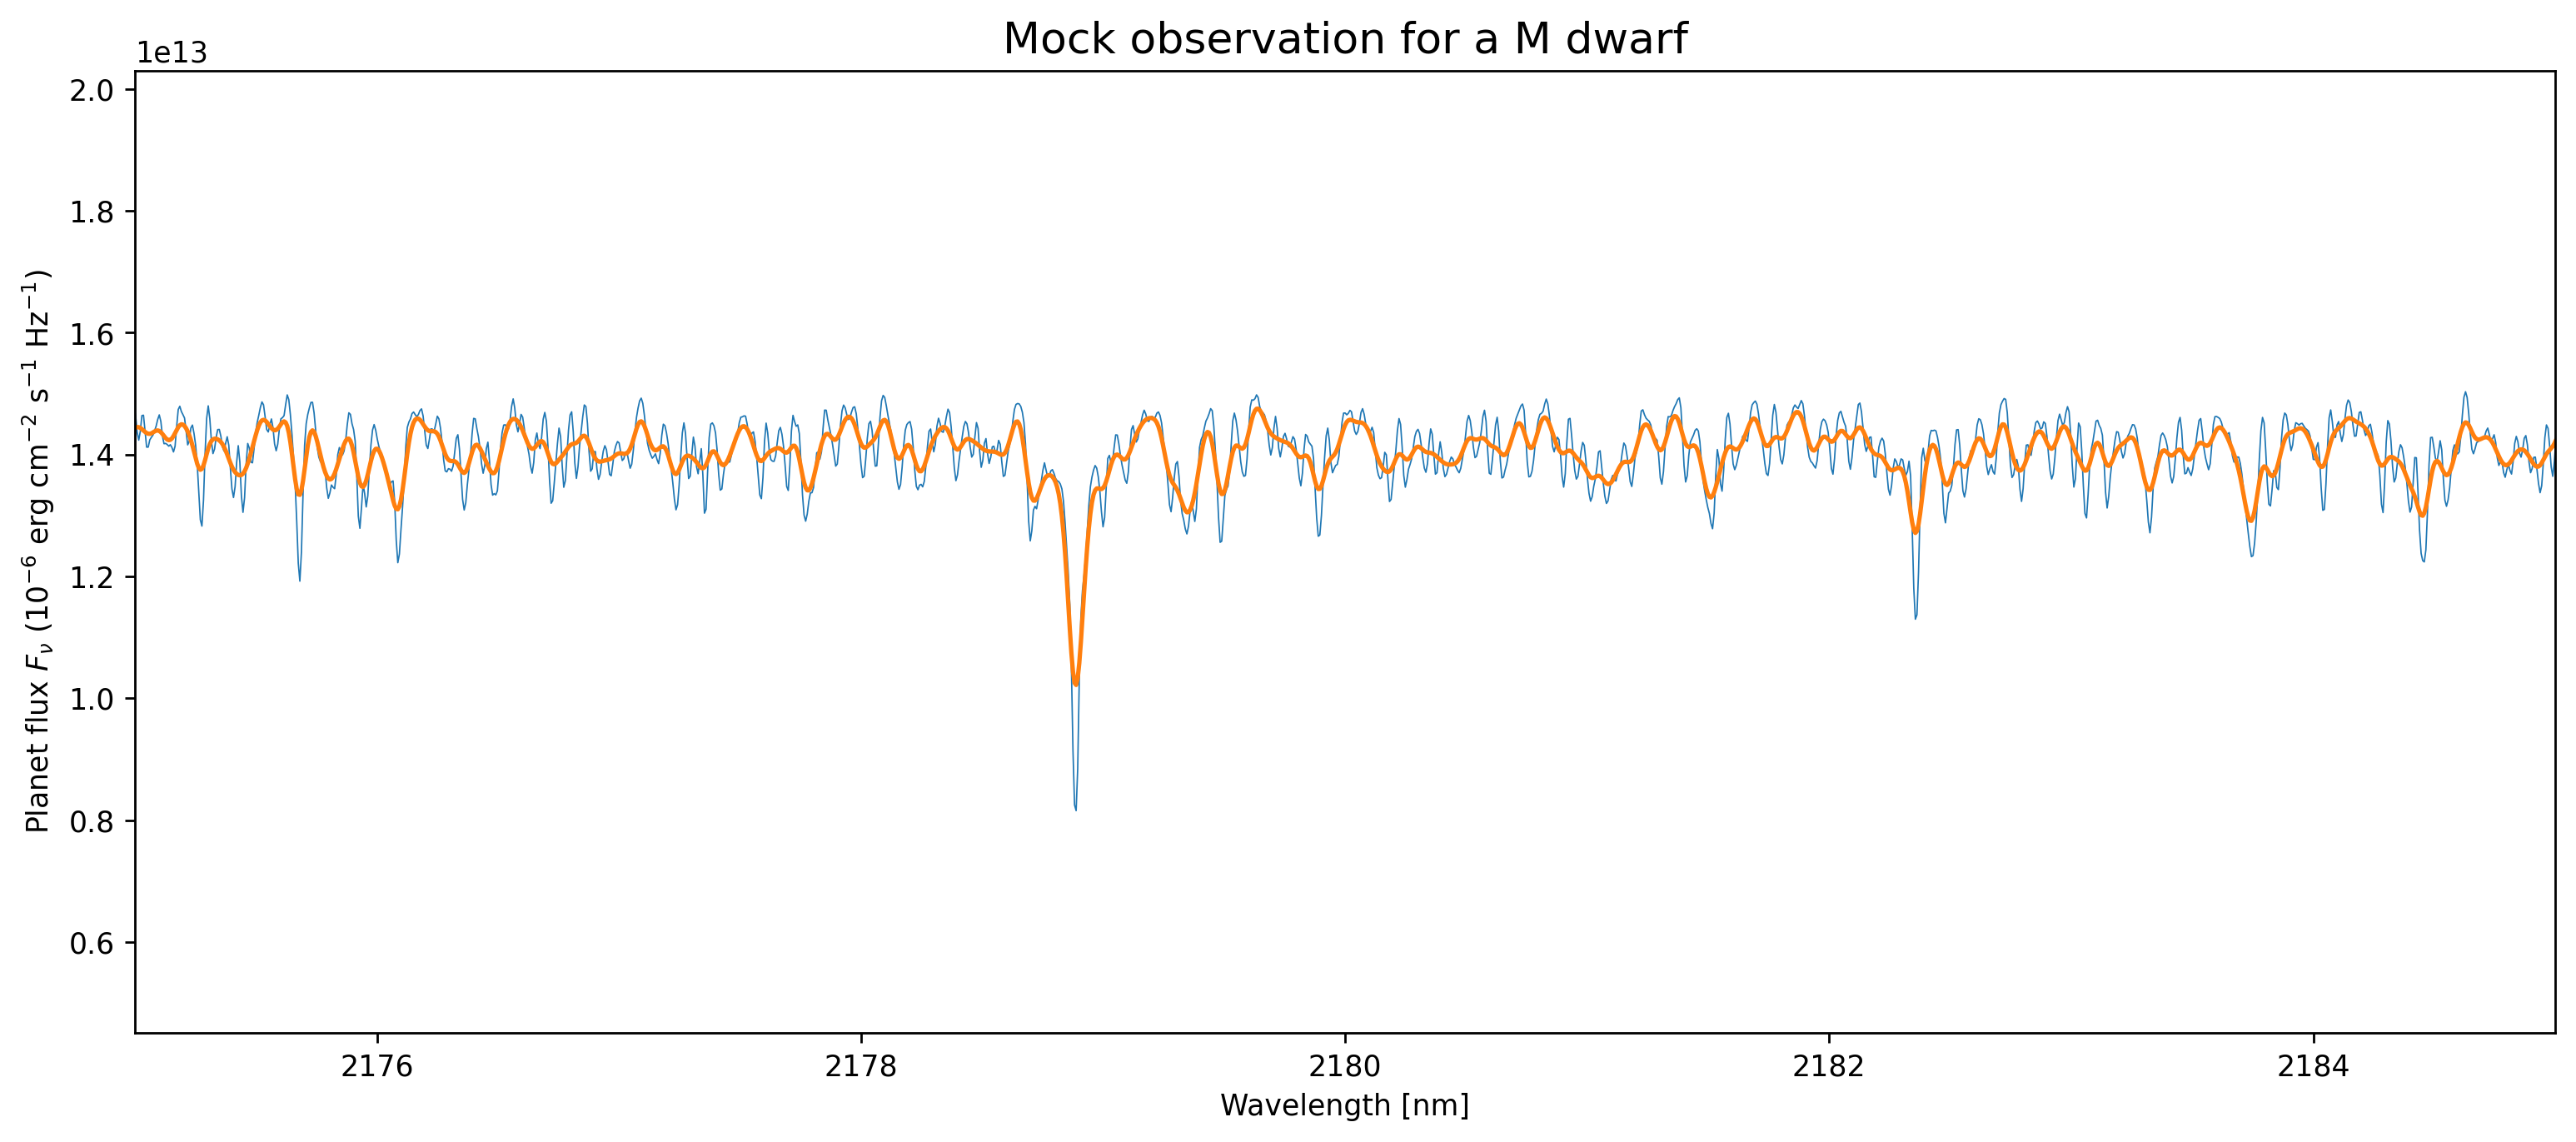

In [21]:
fig, ax = plt.subplots(figsize=(15,6), dpi=250)
ax.plot(wavelength_nm, flux, linewidth=0.5)
ax.plot(wavelength_nm, flux_convolved, linewidth=1.5)
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel(r'Planet flux $F_\nu$ (10$^{-6}$ erg cm$^{-2}$ s$^{-1}$ Hz$^{-1}$)')
ax.set_title('Mock observation for a M dwarf', fontsize=15)

ax.set_xlim(2175, 2185)
# ax.set_xlim(2230, 2245)
# ax.set_xlim(2260, 2275)
# ax.set_xlim(2425, 2430)
# ax.set_xlim(2344, 2347)

calculate the continuum opacity from H- and CIA

In [19]:
hminus = atmosphere._compute_h_minus_opacities(
        mass_fractions=mass_fractions,
        pressures=pressure,
        temperatures=temperature,
        frequencies=atmosphere._frequencies,
        frequency_bins_edges=atmosphere._frequency_bins_edges,
        mean_molar_masses=mean_molar_masses,
        )

    # calculate the cia opacity
cia_opacities = atmosphere._compute_cia_opacities(
        cia_dicts=atmosphere._cias_loaded_opacities,
        mass_fractions=mass_fractions,
        pressures=pressure,
        temperatures=temperature,
        frequencies=atmosphere._frequencies,
        mean_molar_masses=mean_molar_masses,
        )

In [20]:
mass_fractions.keys()

dict_keys(['Na', 'Ca', 'HF', '12CO', 'H2O', 'OH', 'CN', 'TiO', 'e-', 'H2', 'H-', 'Fe', 'Al', 'Mg', 'He', 'K', 'Si', 'Ti', 'H'])

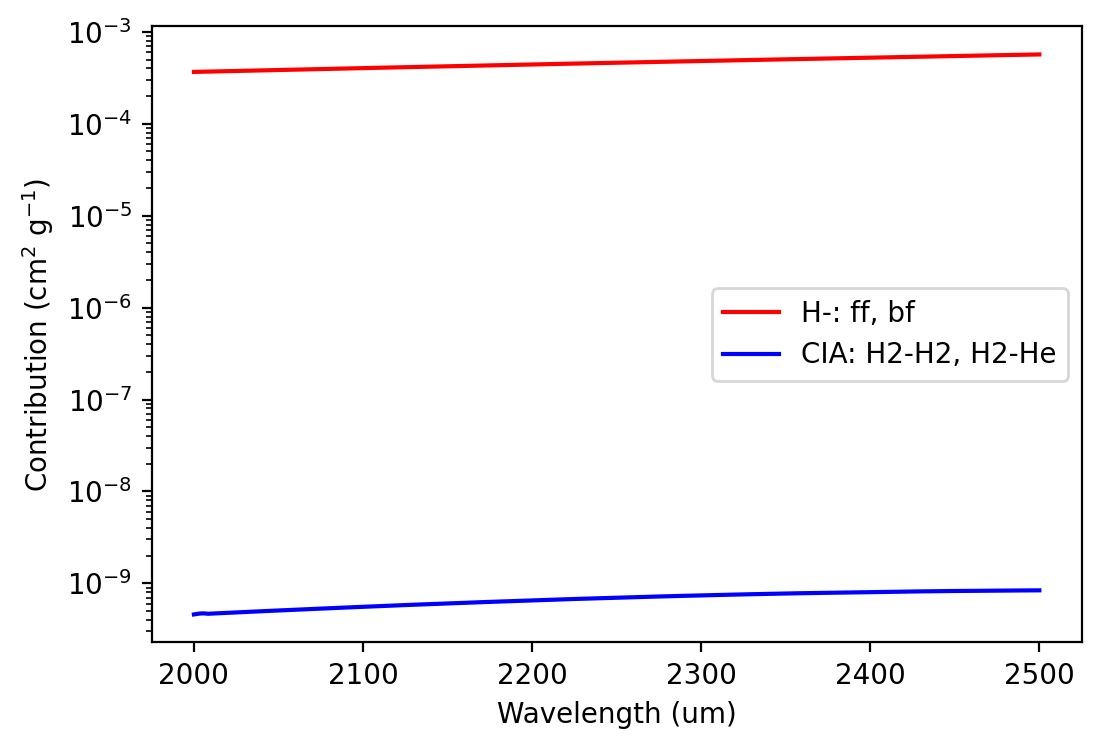

In [22]:
# plot the contribution from H- and CIA opacities
# plot the contribution from H- and CIA opacities
plt.figure(figsize=(6, 4), dpi=200)
# plt.plot(np.mean(hminus, axis=0), pressure_all['fastchem_eqchem'], color='red', label='H-')
# plt.plot(np.mean(cia_opacities, axis=0), pressure_all['fastchem_eqchem'], color='blue', label='CIA')
# plt.xscale('log')
# plt.yscale('log')
# # invert the y-axis
# plt.gca().invert_yaxis()
# plt.legend()

plt.plot(wavelength_nm, np.mean(hminus, axis=1), color='red', label='H-: ff, bf')
plt.plot(wavelength_nm, np.mean(cia_opacities, axis=1), color='blue', label='CIA: H2-H2, H2-He')

plt.xlabel('Wavelength (um)')
plt.ylabel('Contribution (cm$^2$ g$^{-1}$)')
# plt.xscale('log')
plt.yscale('log')
# invert the y-axis
# plt.gca().invert_yaxis()
plt.legend()

## 4. plot contribution

In [36]:
# plot opacity contribution from different molecules.
from petitRADTRANS.plotlib import plot_opacity_contributions

opacity_contributions = plot_opacity_contributions(
    atmosphere,
    mode='emission',  # can also be 'emission'
    fill_below=False,  # if False, contributions are represented as cruves instead as a filled area
    x_axis_scale='linear',  # 'linear' by default
    temperatures=temperatures, 
    mass_fractions=mass_fractions, 
    mean_molar_masses=mean_molar_masses, 
    reference_gravity=reference_gravity, 
)

Generating temporary Radtrans object with 'line_species': 'Na'
Loading Radtrans opacities...
 Loading line opacities of species 'Na' from file '/shared/petitRADTRANS/input_data/opacities/lines/line_by_line/Na/23Na/23Na__Kurucz.R1e+06_0.3-28.0mu.xsec.petitRADTRANS.h5'... Done.
 Successfully loaded all line opacities
Successfully loaded all opacities
Loading Radtrans opacities...
 Loading line opacities of species 'Na' from file '/shared/petitRADTRANS/input_data/opacities/lines/line_by_line/Na/23Na/23Na__Kurucz.R1e+06_0.3-28.0mu.xsec.petitRADTRANS.h5'... Done.
 Successfully loaded all line opacities
Successfully loaded all opacities
Generating temporary Radtrans object with 'line_species': 'Ca'
Loading Radtrans opacities...
 Loading line opacities of species 'Ca' from file '/shared/petitRADTRANS/input_data/opacities/lines/line_by_line/Ca/40Ca/40Ca__Kurucz.R1e+06_0.3-28.0mu.xsec.petitRADTRANS.h5'... Done.
 Successfully loaded all line opacities
Successfully loaded all opacities
Generating

IndexError: list index out of range